In [84]:
import numpy as np 
import cv2 as cv
from matplotlib import pyplot as plt
import imutils
import easyocr

In [85]:
car_img = cv.imread("E:\\New folder (6)\\jRkYmU3MmZkM.jpg")

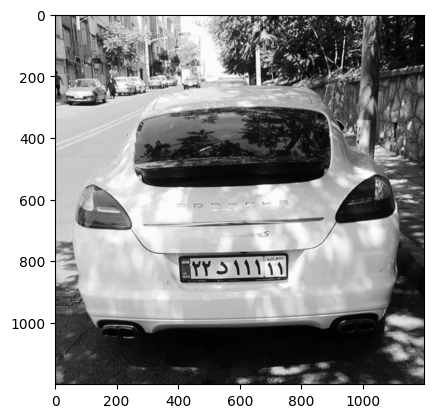

In [86]:
car_img_gray = cv.cvtColor(car_img, cv.COLOR_BGR2GRAY)
plt.imshow(cv.cvtColor(car_img_gray, cv.COLOR_BGR2RGB))

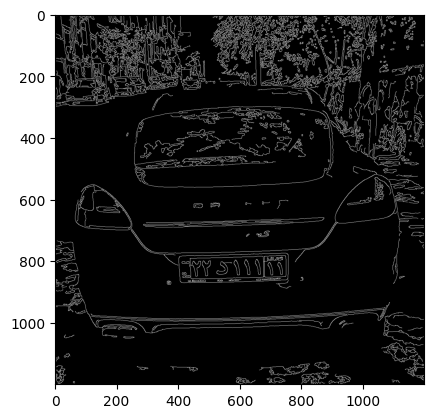

In [87]:
blateral_filtered = cv.bilateralFilter(car_img_gray, 11, 15, 15)
edges = cv.Canny(blateral_filtered, 30 , 200)
plt.imshow(cv.cvtColor(edges, cv.COLOR_BGR2RGB))

In [88]:
contours = cv.findContours(edges.copy(), cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
contours_refined = imutils.grab_contours(contours)
print(contours_refined[0])
contours_sorted =sorted(contours_refined, key = cv.contourArea, reverse = True)[:4]

[[[ 844 1197]]

 [[ 843 1198]]

 [[ 843 1199]]

 [[ 843 1198]]

 [[ 844 1197]]

 [[ 846 1199]]

 [[ 846 1198]]

 [[ 845 1198]]]


In [89]:
for contour in contours_sorted:
    contour_approx = cv.approxPolyDP(contour, 10, True)
    if len(contour_approx) == 4: 
        plate_location = contour_approx
        break

In [90]:
plate_location

array([[[756, 780]],

       [[407, 785]],

       [[405, 865]],

       [[749, 862]]], dtype=int32)

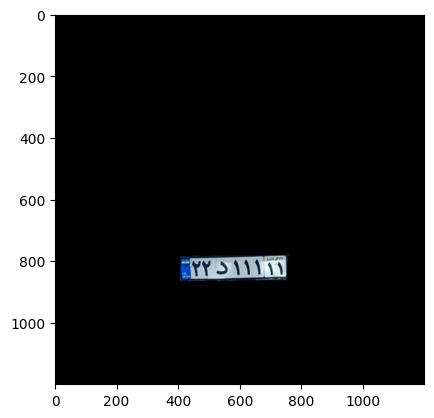

In [91]:
plate_mask0 = np.zeros(car_img_gray.shape, np.uint8)
plate_mask = cv.drawContours(plate_mask0, [plate_location], 0, 255, -1)
plate_img = cv.bitwise_and(car_img, car_img, mask = plate_mask)
plt.imshow(cv.cvtColor(plate_img, cv.COLOR_BGR2RGB))

In [92]:
cv.imwrite("E:\\New folder (6)\\plate_en2.png", plate_img)

True

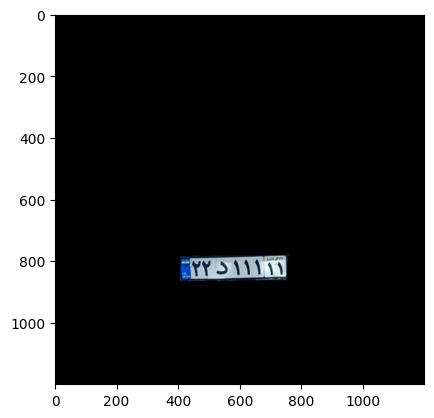

In [93]:
car_img = cv.imread('E:\\New folder (6)\\plate_en2.png')
car_plate_img = cv.imread('E:\\New folder (6)\\plate_en2.png')
plt.imshow(cv.cvtColor(car_plate_img, cv.COLOR_BGR2RGB))

In [94]:
reader = easyocr.Reader(['fa'])
plate_text = reader.readtext(car_plate_img)
print(plate_text)

Progress: |██████████████████████████████████████████████████| 100.0% Complete[[[[np.int32(430), np.int32(784)], [np.int32(750), np.int32(784)], [np.int32(750), np.int32(862)], [np.int32(430), np.int32(862)]], '٢٧ ١ ١١ ٥ ٢٢', np.float64(0.1895722097321045)]]
